<a href="https://colab.research.google.com/github/Raffi38321/Regresi_5C_Tim8ML/blob/main/ML_TIM_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

In [ ]:
# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


In [ ]:
!kaggle datasets download -d shivam2503/diamonds

Dataset URL: https://www.kaggle.com/datasets/shivam2503/diamonds
License(s): unknown
100% 733k/733k [00:00<00:00, 97.4MB/s]



In [ ]:

!unzip -q diamonds.zip -d diamonds

print("Unduhan dan Ekstraksi Selesai!")

Unduhan dan Ekstraksi Selesai!


In [ ]:
import pandas as pd
df = pd.read_csv('diamonds/diamonds.csv')

In [ ]:
# Menampilkan 5 baris pertama untuk memastikan koneksi dan load data berhasil

display(df.head())

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
print(df['cut'].unique())
print(df['color'].unique())
print(df['clarity'].unique())

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['E' 'I' 'J' 'H' 'F' 'G' 'D']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


cut memiliki urutan Fair < Good < Very Good < Premium < Ideal
color memiliki urutanJ < I < H < G < F < E < D
clarity memiliki urutan I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF




## **Inspeksi Awal Data (Initial Data Inspection)**

In [ ]:
# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



--- 5 Baris Terakhir Data ---


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64



Dimensi dataset: 53940 baris, 11 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB

--- Daftar Nama Kolom ---
['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


Dataset ini berisi data karakteristik fisik dan tingkat kualitas dari 53.940 sampel berlian beserta harganya. Dataset terdiri dari 11 kolom yang mencakup variabel numerik dan kategorik (ordinal)

Jumlah Observasi: 53.940 baris

Jumlah Fitur: 11 kolom (8 numerik, 3 kategorik)


## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


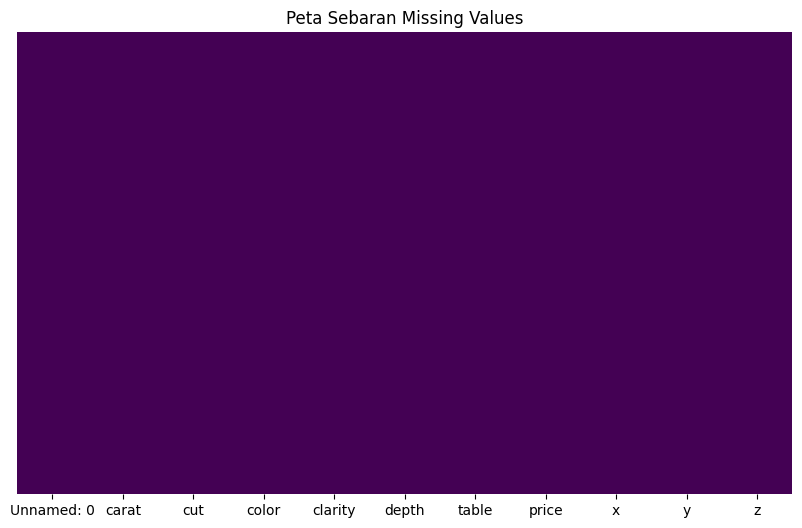


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
display(missing_table[missing_table['Jumlah Missing'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")

tidak ada missing values dan duplikat



## **Statistik Deskriptif (Descriptive Statistics)**

In [ ]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


1. Analisis Fitur Numerik

Berdasarkan hasil kalkulasi statistik deskriptif pada 53.940 observasi, berikut adalah karakteristik utama dari variabel-variabel numerik:
A. Harga Berlian (price)

Pusat & Sebaran Data: Rata-rata harga berlian dalam dataset adalah $3,932.80 dengan standar deviasi yang sangat tinggi yaitu $3,989.44, menunjukkan variasi harga yang sangat lebar antar-sampel.

Kemiringan Distribusi (Right-Skewed): Nilai median ($2,401.00) jauh lebih rendah dibandingkan nilai rata-rata ($3,932.80), serta 75% data berada di bawah $5,324.25. Ini menandakan mayoritas berlian berharga relatif terjangkau, sedangkan sebagian kecil berlian mewah bernilai tinggi (hingga $18,823.00) menarik nilai rata-rata ke atas.

B. Berat Berlian (carat)

Distribusi Ukuran: Berat rata-rata berlian adalah 0.80 karat dengan median 0.70 karat. Rentang karat berkisar antara 0.20 karat (terkecil) hingga 5.01 karat (terbesar).

Pola Konsentrasi: Lebih dari 50% data berukuran antara 0.40 hingga 1.04 karat (rentang Interquartile Range / IQR). Sama seperti harga, distribusi karat juga miring ke kanan (right-skewed).

C. Dimensi Fisik (x, y, z)

Rata-Rata Dimensi: Panjang (x) dan lebar (y) memiliki rata-rata yang hampir identik yaitu sekitar 5.73 mm, sedangkan kedalaman (z) memiliki rata-rata 3.54 mm.

Indikasi Data Tidak Valid (Zero Values): Nilai minimum pada x, y, dan z menunjukkan angka 0.00 mm. Secara fisik, objek 3D seperti berlian tidak mungkin berdimensi nol. Ini merupakan indikasi adanya missing values atau kesalahan pencatatan data.

Indikasi Pencilan Ekstrem (Typo Data): Nilai maksimum pada y (58.90 mm) dan z (31.80 mm) sangat jauh melonjak dari persentil 75% (y: 6.54 mm, z: 4.04 mm). Ini merupakan indikasi kuat data entry error (salah ketik) yang perlu dibersihkan.

D. Proporsi Potongan (depth & table)

Stabilitas Data: Fitur depth (rata-rata 61.75%, std 1.43) dan table (rata-rata 57.46%, std 2.23) memiliki sebaran yang sangat stabil dengan varians yang kecil.

Outlier Proporsi: Terdapat nilai ekstrem pada batas minimum (43.00%) dan maksimum (depth: 79.00%, table: 95.00%) yang dapat dikategorikan sebagai outlier statistik.

2. Analisis Fitur Kategorik (Objek)Terdapat 3 fitur kategorik yang merepresentasikan standar kualitas berlian, dengan ringkasan sebagai berikut

- Kualitas Potongan (cut): Didominasi oleh potongan kualitas terbaik, yaitu Ideal sebanyak 21,551 sampel (~40% dari total dataset).

- Tingkat Warna (color): Warna kelas G (kategori sedang/bagus) menjadi kelas yang paling banyak muncul, yaitu sebanyak 11,292 sampel (~21%).

- Kejernihan (clarity): Kategori kejernihan SI1 (Slightly Included 1) merupakan kategori terbanyak dengan 13,065 sampel (~24%).

## **Analisis Univariat (Univariate Analysis)**

### Analisis Univariat untuk Kolom Numerik ###


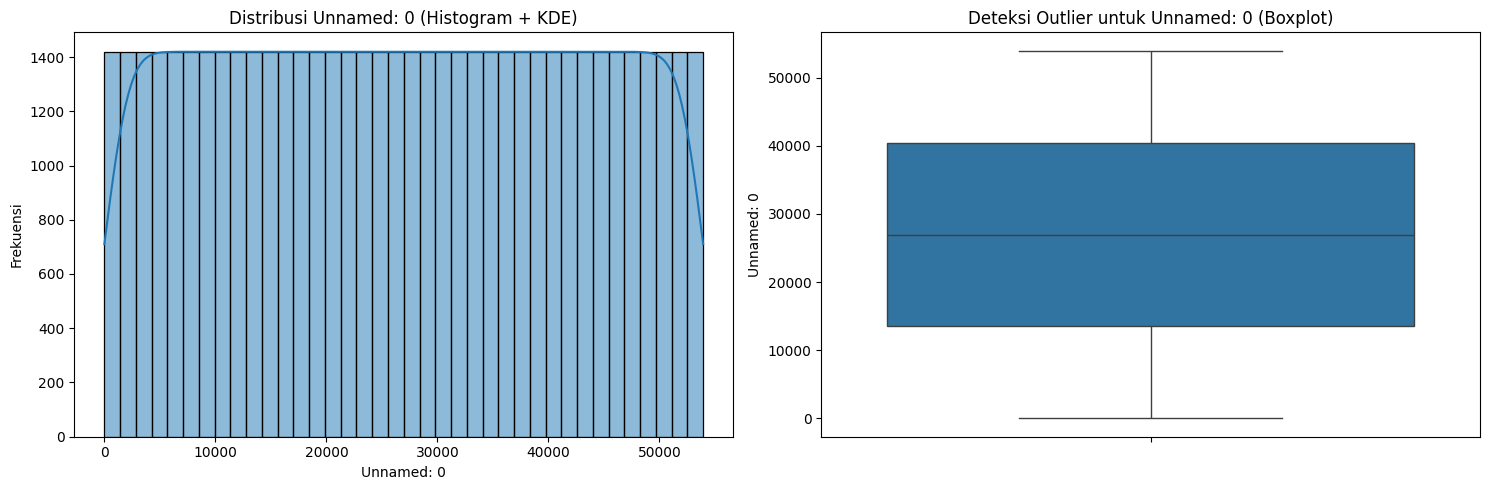

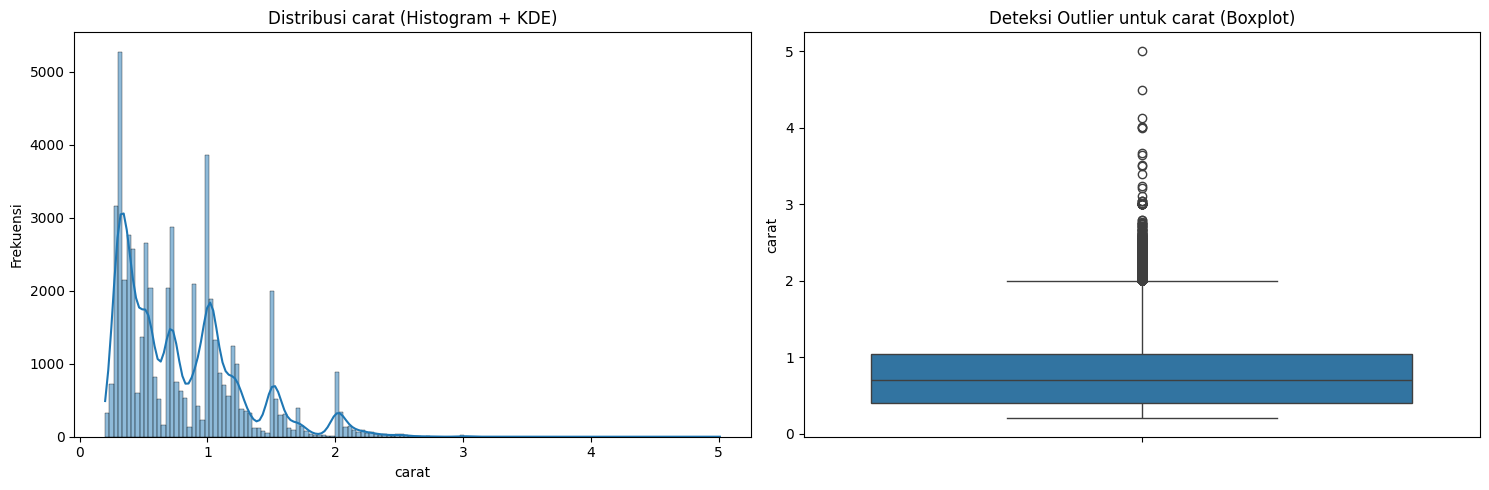

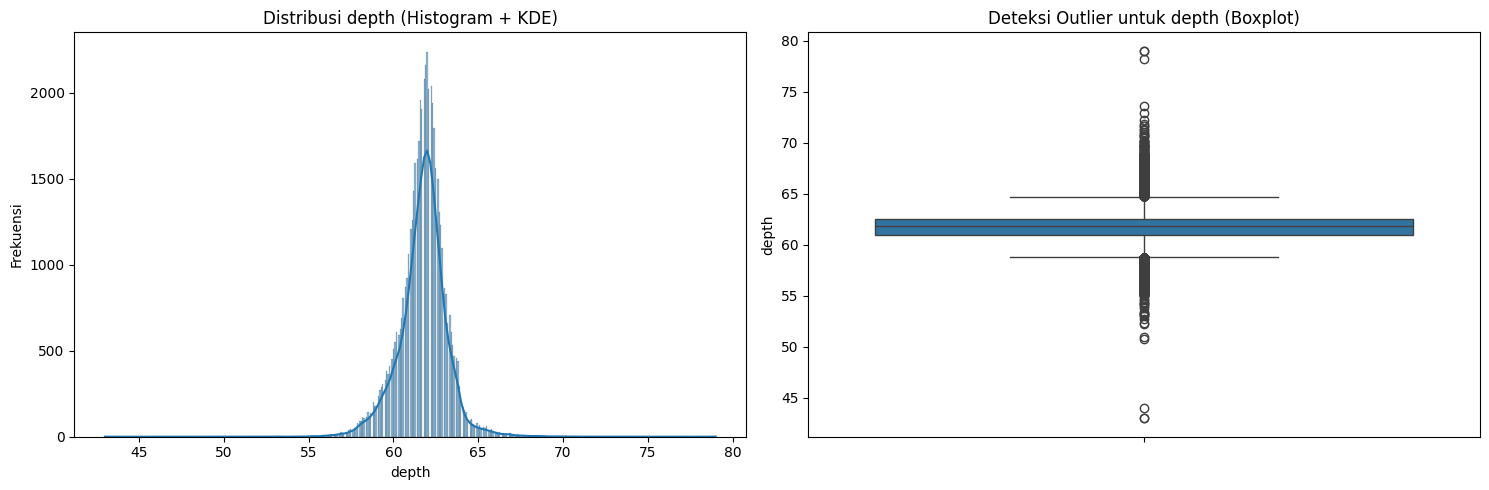

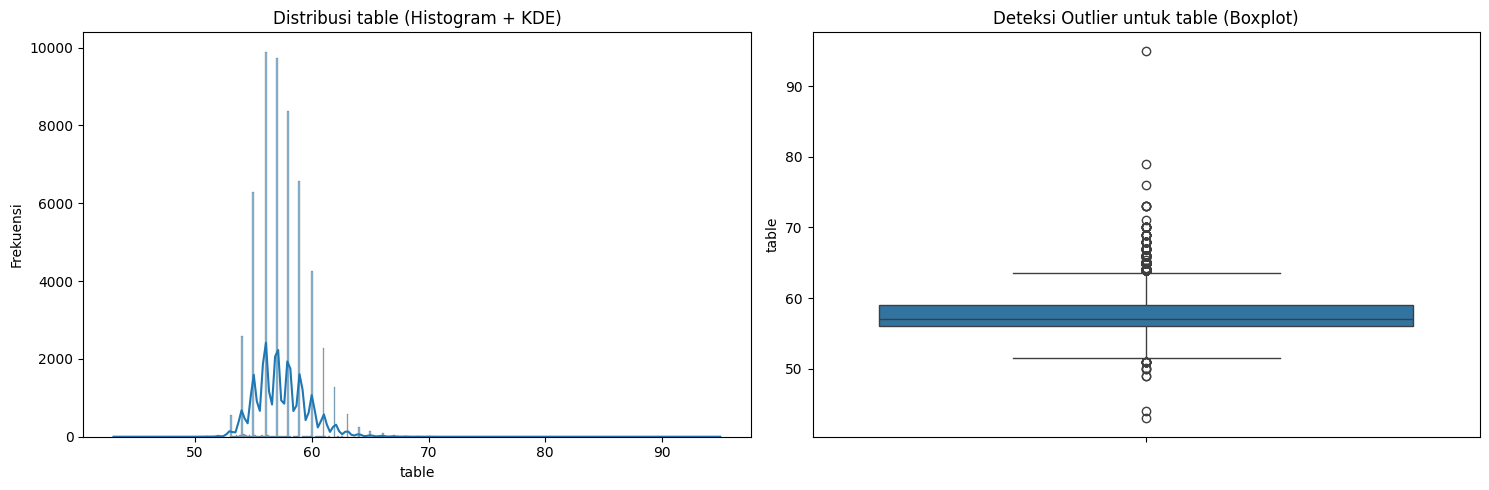

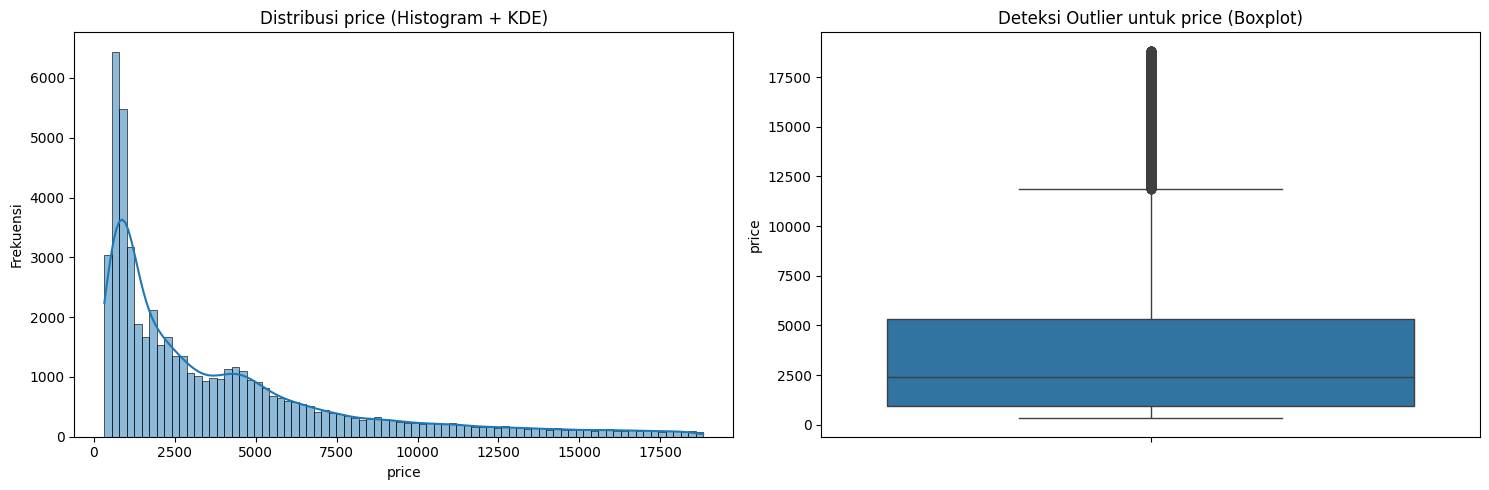

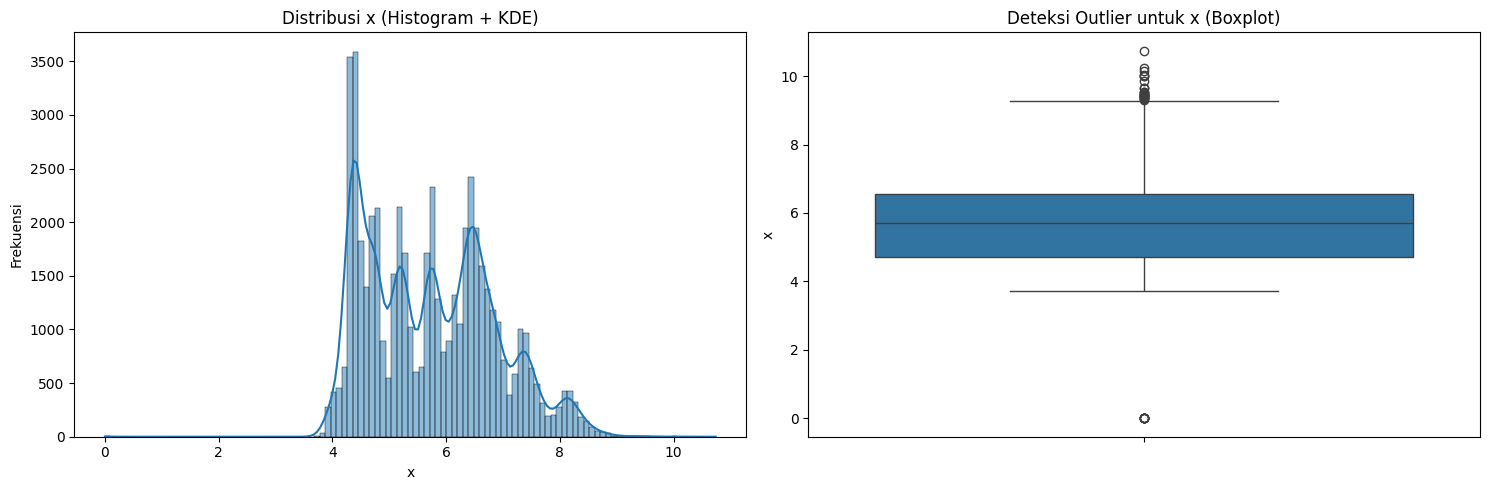

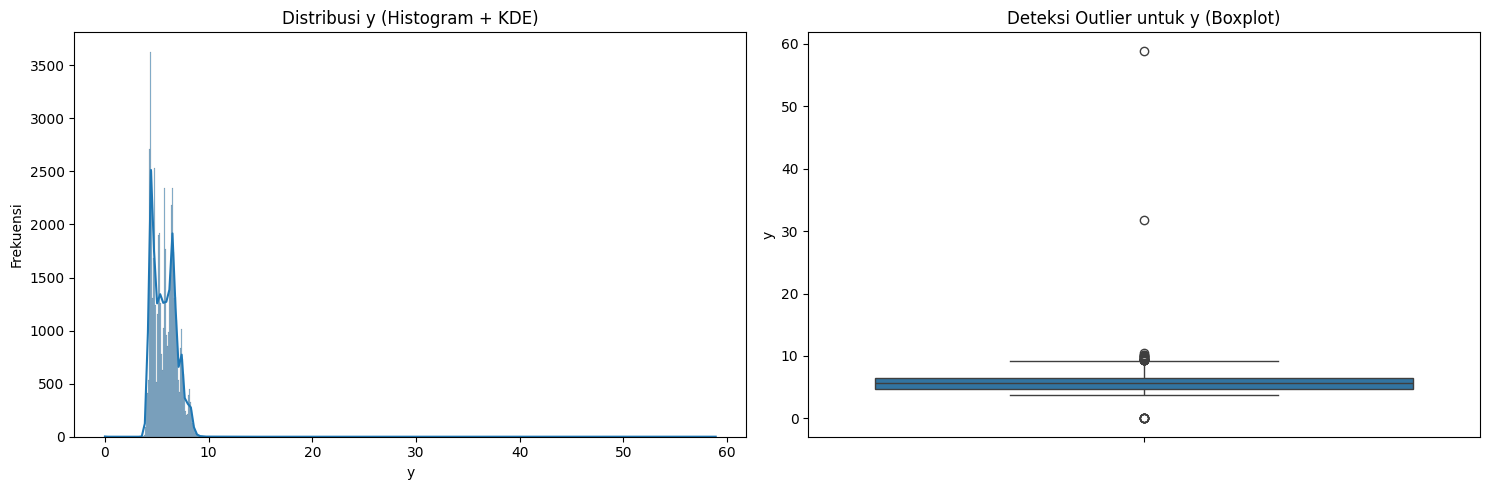

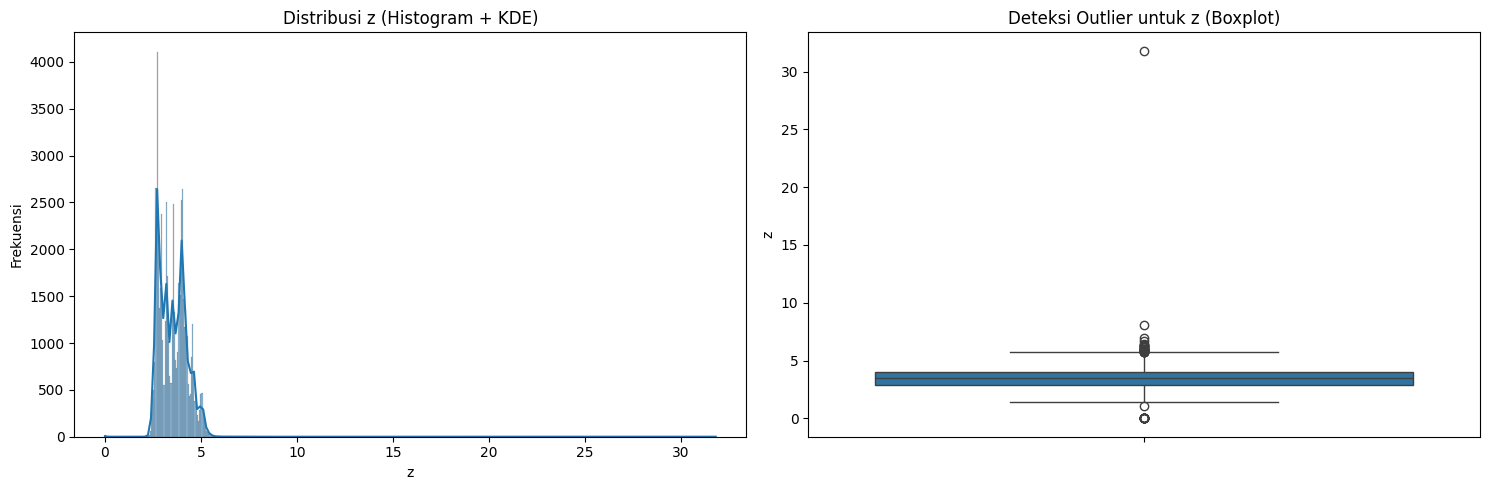


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_925/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


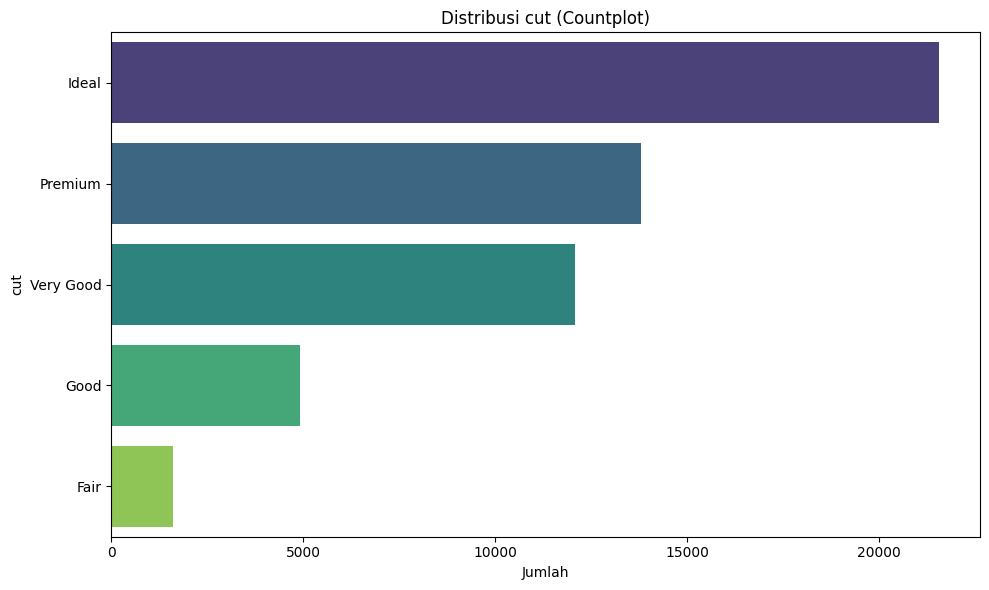

/tmp/ipykernel_925/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


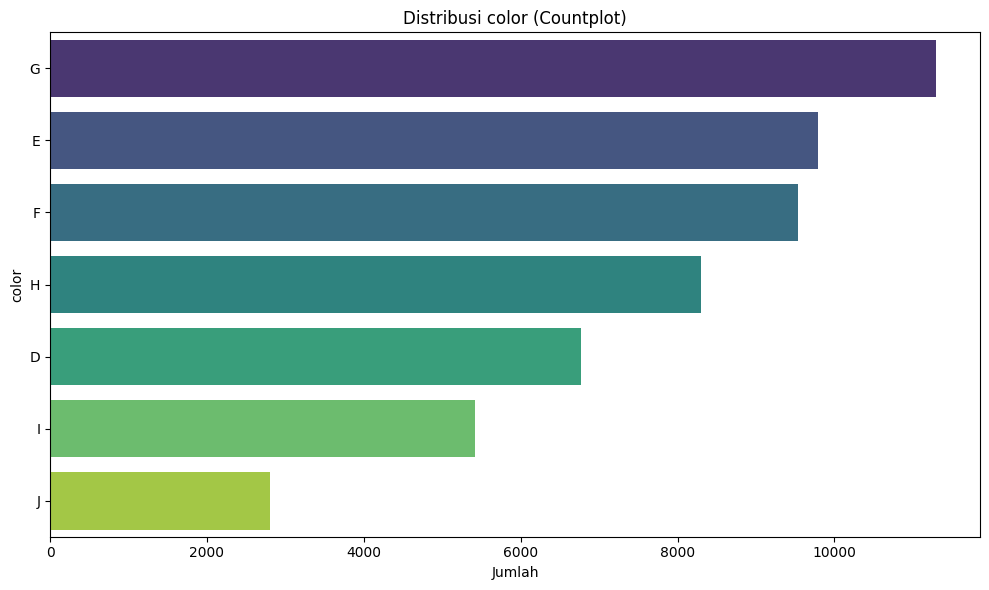

/tmp/ipykernel_925/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


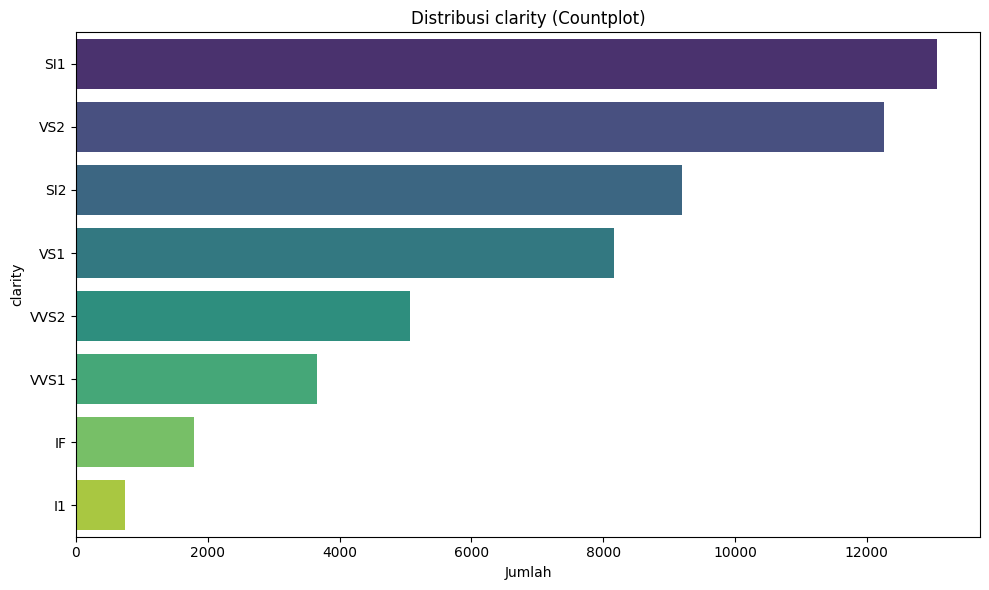

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


anal anal
ya pokonya banyak outliernya ini harus di anal lebih lanjut mau dihapus, atau diganti nilainya (pelajari lebih kanjut)

## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**

In [ ]:
df.columns.to_list()

['Unnamed: 0',
 'carat',
 'cut',
 'color',
 'clarity',
 'depth',
 'table',
 'price',
 'x',
 'y',
 'z']

### 1. Heatmap Korelasi Antar Kolom Numerik ###


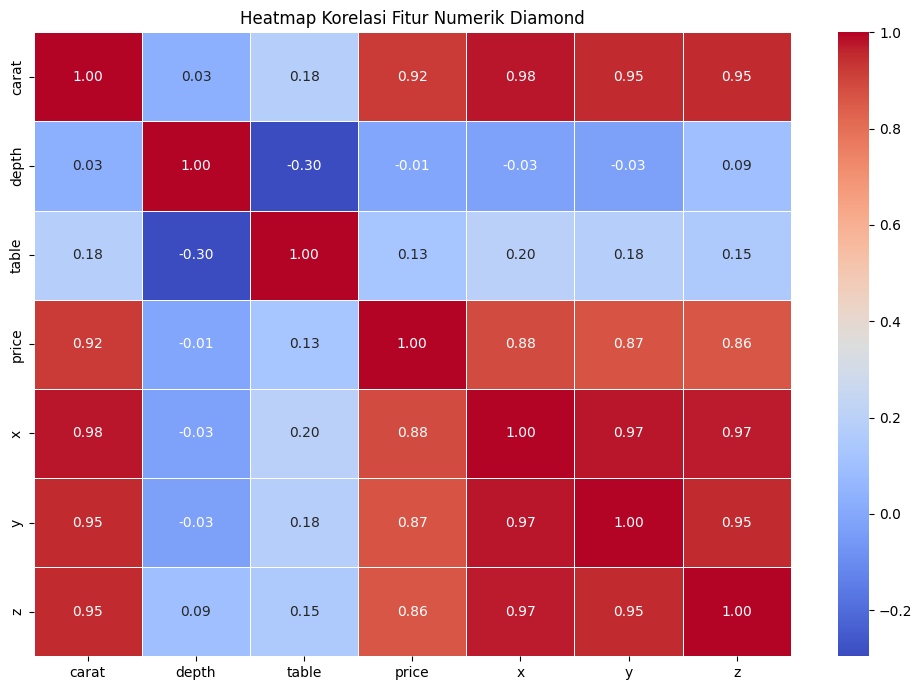


### 2. Scatter Plot Fitur Numerik terhadap Price ###


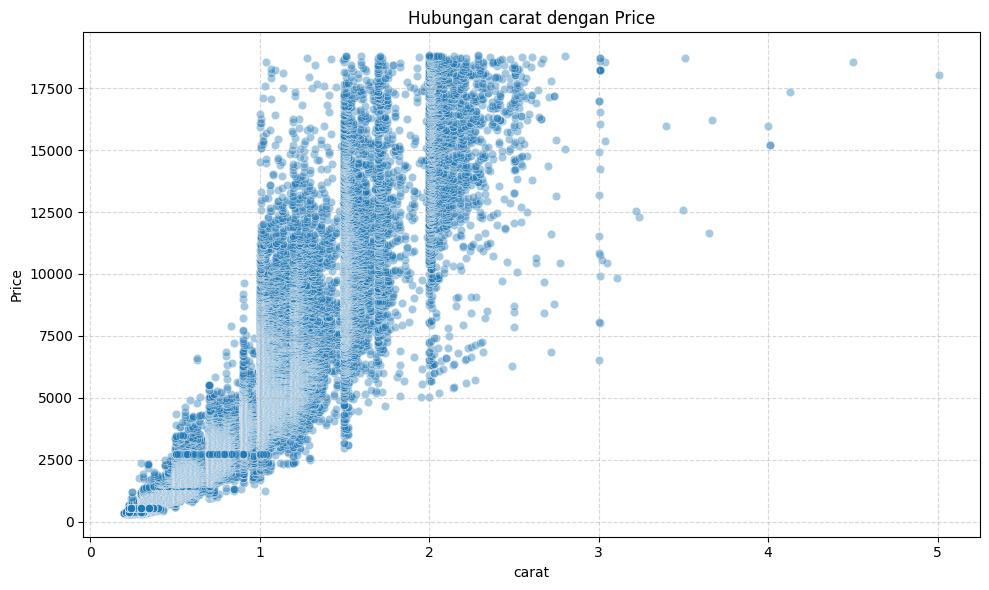

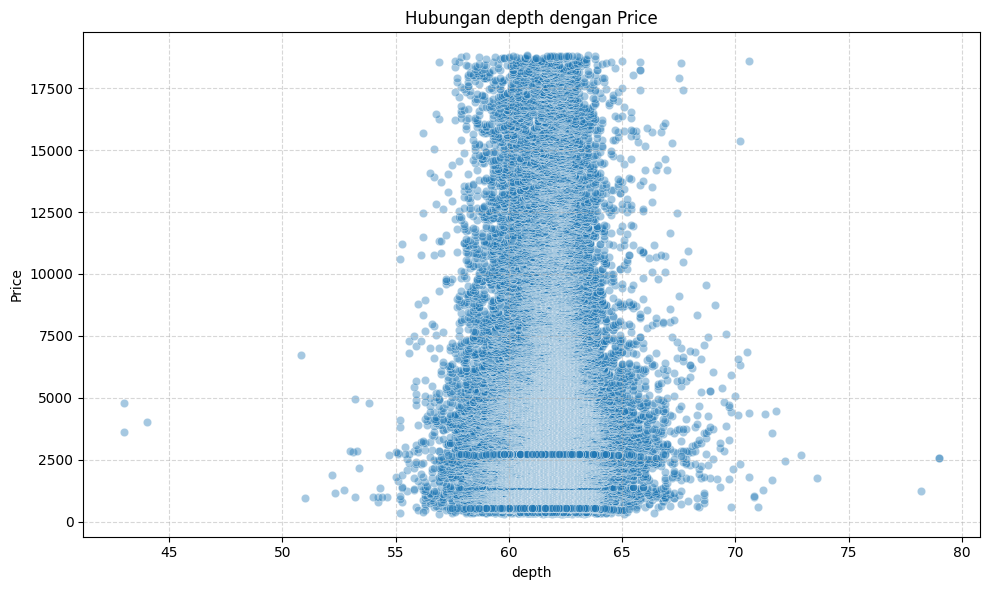

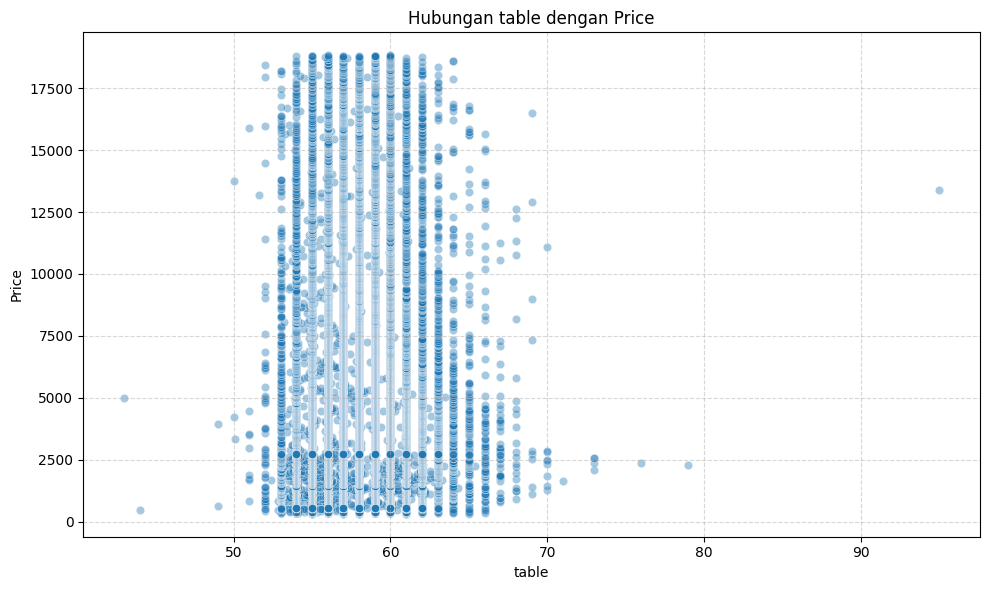

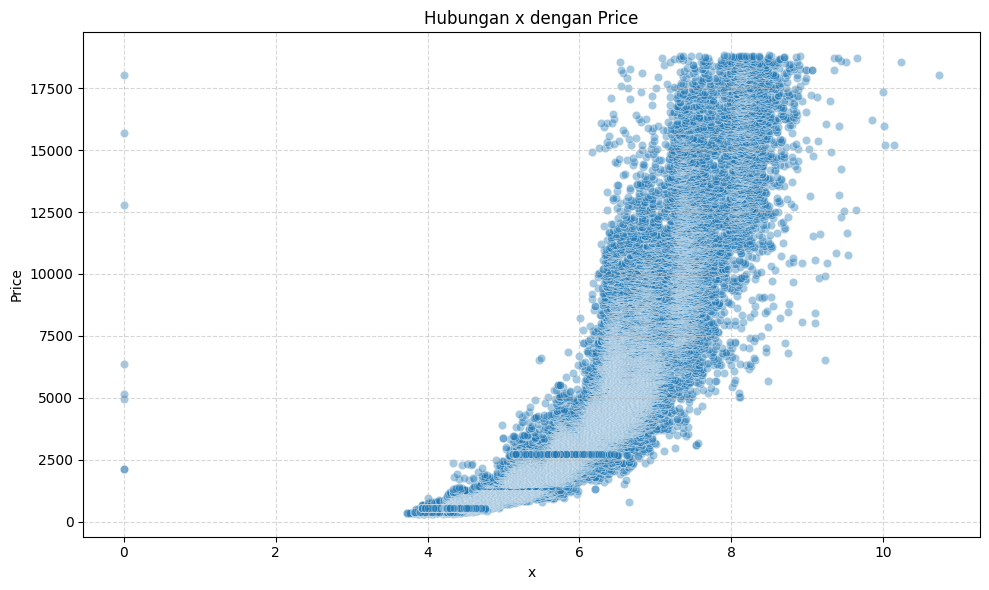

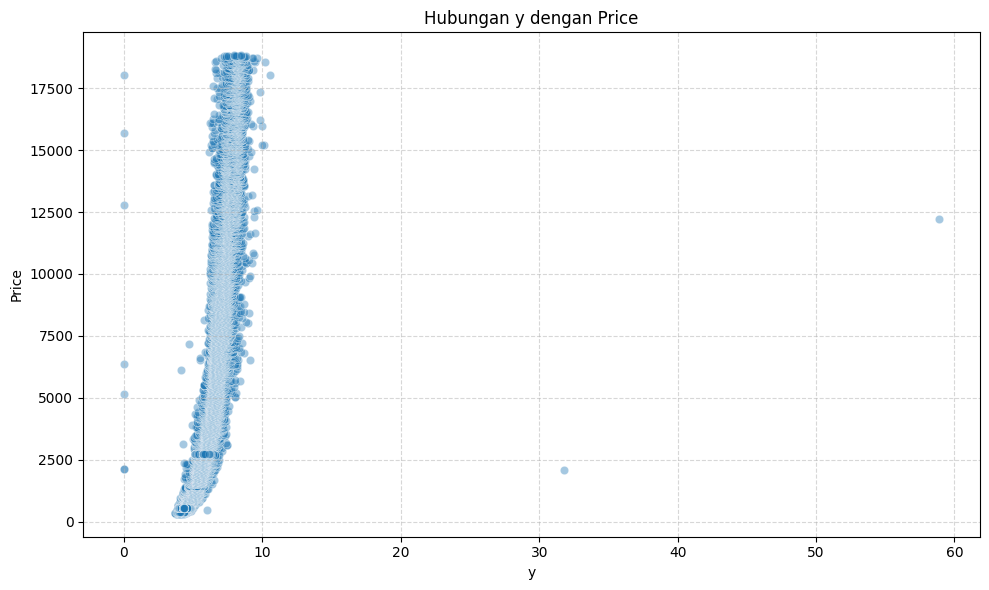

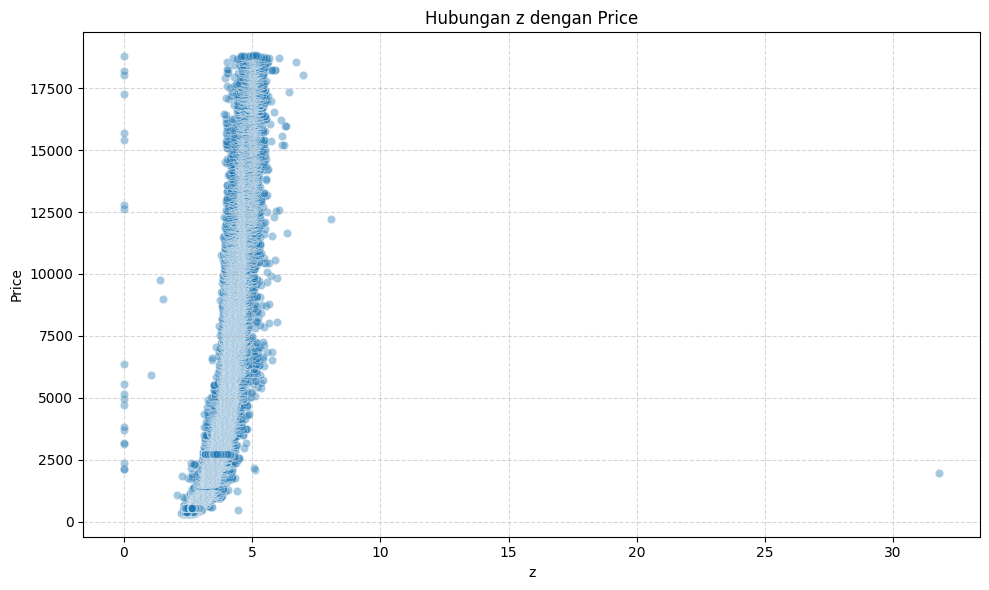


### 3. Hubungan Carat dan Price Berdasarkan Kategori ###


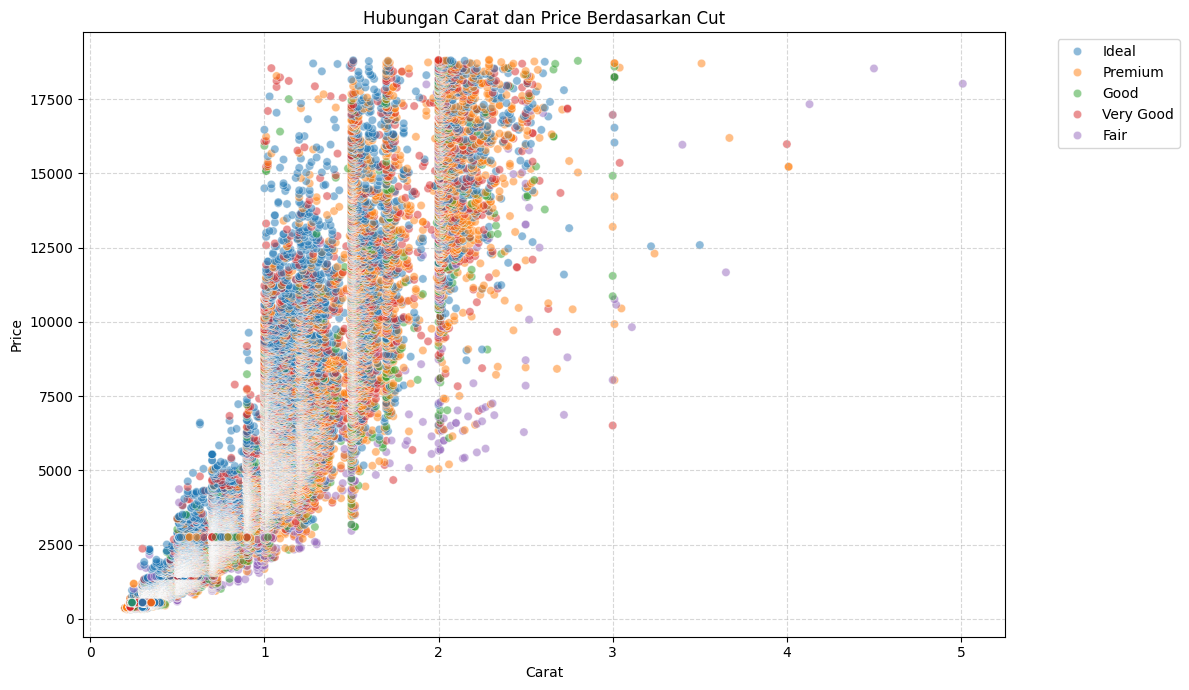


### 4. Boxplot Price Berdasarkan Kolom Kategorikal ###


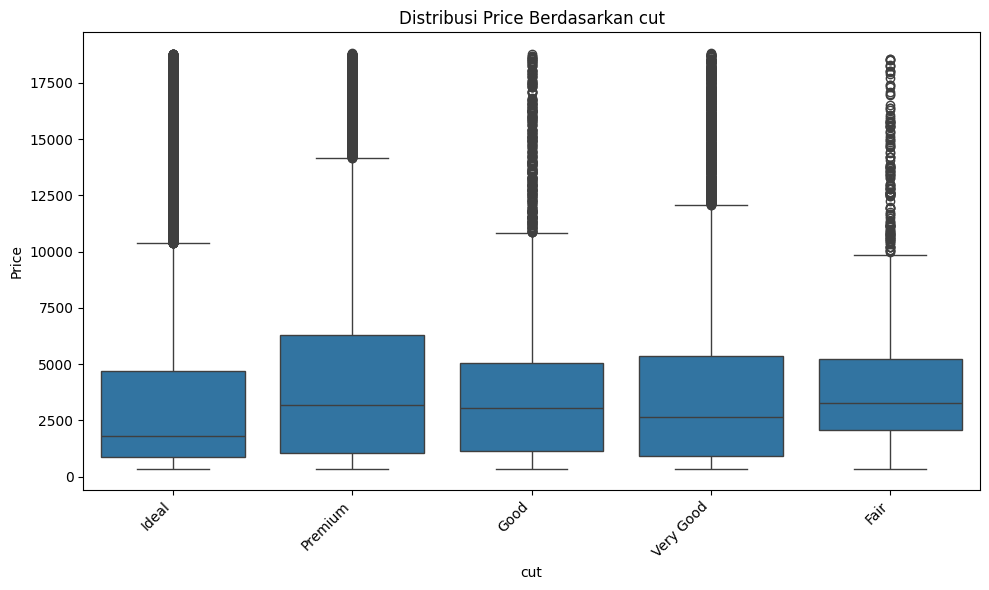

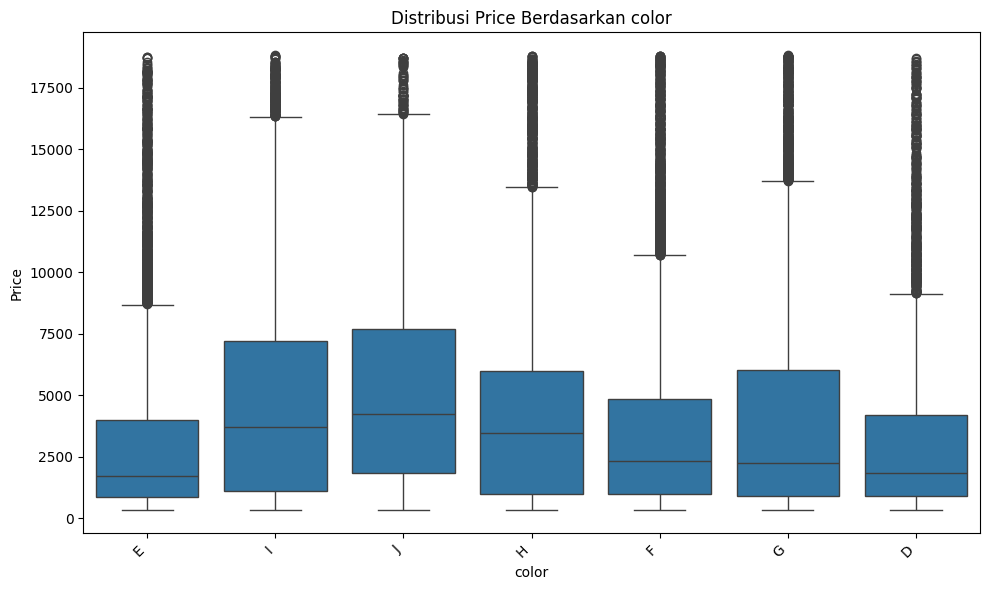

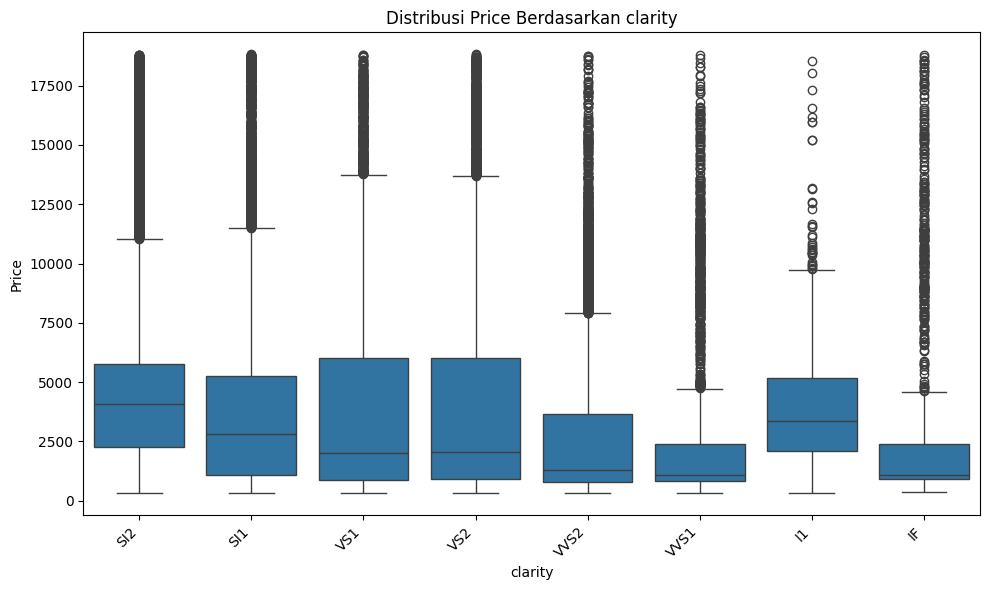

In [ ]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

# Buang kolom index yang tidak relevan
if 'Unnamed: 0' in kolom_numerik:
    kolom_numerik.remove('Unnamed: 0')


# =========================================================
# 1. Heatmap Korelasi Antar Kolom Numerik
# =========================================================

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")

plt.figure(figsize=(10, 7))

correlation_matrix = df[kolom_numerik].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap Korelasi Fitur Numerik Diamond')
plt.tight_layout()
plt.show()


# =========================================================
# 2. Scatter Plot Fitur Numerik terhadap Price
# =========================================================

print("\n### 2. Scatter Plot Fitur Numerik terhadap Price ###")

fitur_numerik = [
    'carat',
    'depth',
    'table',
    'x',
    'y',
    'z'
]

for kolom in fitur_numerik:
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=kolom,
        y='price',
        alpha=0.4
    )

    plt.title(f'Hubungan {kolom} dengan Price')
    plt.xlabel(kolom)
    plt.ylabel('Price')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# =========================================================
# 3. Scatter Plot dengan Variabel Kategorikal
# =========================================================

print("\n### 3. Hubungan Carat dan Price Berdasarkan Kategori ###")

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',
    alpha=0.5
)

plt.title('Hubungan Carat dan Price Berdasarkan Cut')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# =========================================================
# 4. Boxplot Numerik Berdasarkan Kategori
# =========================================================

print("\n### 4. Boxplot Price Berdasarkan Kolom Kategorikal ###")

for kat_kolom in kolom_kategorikal:

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x=kat_kolom,
        y='price'
    )

    plt.title(f'Distribusi Price Berdasarkan {kat_kolom}')
    plt.xlabel(kat_kolom)
    plt.ylabel('Price')

    plt.xticks(
        rotation=45,
        ha='right'
    )

    plt.tight_layout()
    plt.show()

ini sebelum yang kategorikal di encoding

## Nyoba preprocessing

ini pas udah di pake encoding

In [ ]:
df['cut'] = df['cut'].map({
    'Fair': 1,
    'Good': 2,
    'Very Good': 3,
    'Premium': 4,
    'Ideal': 5
})

df['color'] = df['color'].map({
    'J': 1,
    'I': 2,
    'H': 3,
    'G': 4,
    'F': 5,
    'E': 6,
    'D': 7
})

df['clarity'] = df['clarity'].map({
    'I1': 1,
    'SI2': 2,
    'SI1': 3,
    'VS2': 4,
    'VS1': 5,
    'VVS2': 6,
    'VVS1': 7,
    'IF': 8
})

### 1. Heatmap Korelasi Antar Kolom Numerik ###


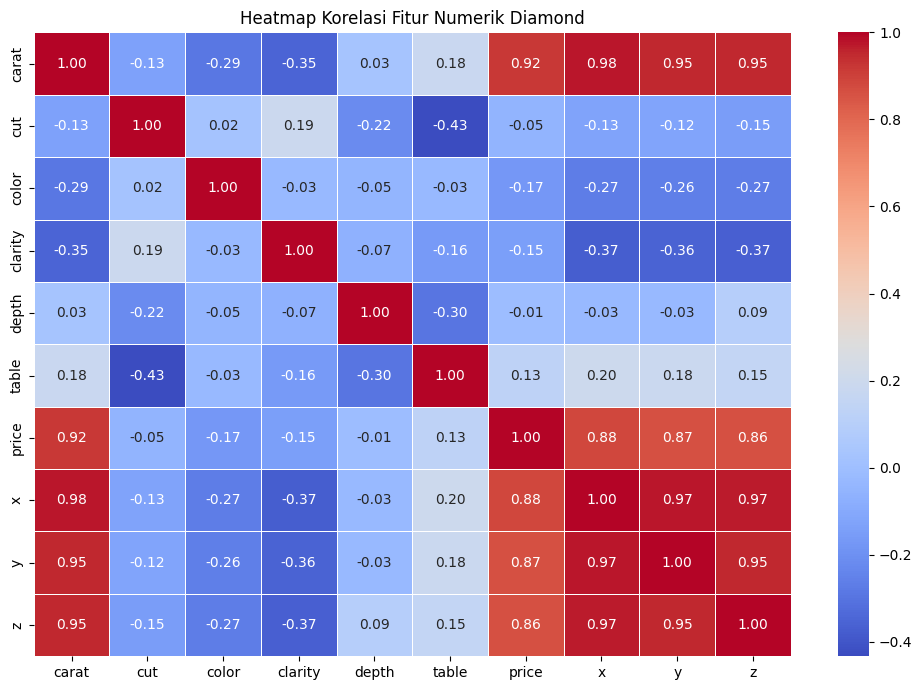

In [ ]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

# Buang kolom index yang tidak relevan
if 'Unnamed: 0' in kolom_numerik:
    kolom_numerik.remove('Unnamed: 0')


# =========================================================
# 1. Heatmap Korelasi Antar Kolom Numerik
# =========================================================

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")

plt.figure(figsize=(10, 7))

correlation_matrix = df[kolom_numerik].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap Korelasi Fitur Numerik Diamond')
plt.tight_layout()
plt.show()


In [ ]:
print('x = 0:', (df['x'] == 0).sum())
print('y = 0:', (df['y'] == 0).sum())
print('z = 0:', (df['z'] == 0).sum())

x = 0: 8
y = 0: 7
z = 0: 20


In [ ]:
print(df.nlargest(10, 'y')[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']])

print("\n--- Z terbesar ---")
print(df.nlargest(10, 'z')[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']])

       carat  depth  table  price      x      y     z
24067   2.00   58.9   57.0  12210   8.09  58.90  8.06
49189   0.51   61.8   55.0   2075   5.15  31.80  5.12
27415   5.01   65.5   59.0  18018  10.74  10.54  6.98
27630   4.50   65.8   58.0  18531  10.23  10.16  6.72
25998   4.01   61.0   61.0  15223  10.14  10.10  6.17
25999   4.01   62.5   62.0  15223  10.02   9.94  6.24
26444   4.00   63.3   58.0  15984  10.01   9.94  6.31
27130   4.13   64.8   61.0  17329  10.00   9.85  6.43
26534   3.67   62.4   56.0  16193   9.86   9.81  6.13
27679   3.51   62.5   59.0  18701   9.66   9.63  6.03

--- Z terbesar ---
       carat  depth  table  price      x      y      z
48410   0.51   61.8   54.7   1970   5.12   5.15  31.80
24067   2.00   58.9   57.0  12210   8.09  58.90   8.06
27415   5.01   65.5   59.0  18018  10.74  10.54   6.98
27630   4.50   65.8   58.0  18531  10.23  10.16   6.72
27130   4.13   64.8   61.0  17329  10.00   9.85   6.43
23644   3.65   67.1   53.0  11668   9.53   9.48   6.38
2

In [ ]:
df_clean = df[
    (df["x"] > 0)
    & (df["y"] > 0)
    & (df["z"] > 0)
    & (df["y"] < 30)
    & (df["z"] < 30)
].copy()


def remove_iqr_outliers(df, columns, factor=1.5):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (factor * IQR)
        upper_bound = Q3 + (factor * IQR)
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df.reset_index(drop=True)


df_clean = remove_iqr_outliers(df_clean, columns=["depth", "table"], factor=1.5)

In [ ]:
df_clean.describe()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
count,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000,50988.000000
mean,27096.313760,0.786542,4.014827,4.411450,4.092571,61.782751,57.298590,3897.416510,5.702690,5.706572,3.524170
std,15447.373338,0.468907,1.013170,1.698204,1.643551,1.111272,2.024016,3986.239041,1.116512,1.109503,0.689444
min,1.000000,0.200000,1.000000,1.000000,1.000000,58.800000,51.600000,326.000000,3.730000,3.680000,1.070000
25%,13805.750000,0.390000,3.000000,3.000000,3.000000,61.100000,56.000000,928.000000,4.690000,4.700000,2.890000
50%,27265.500000,0.700000,4.000000,4.000000,4.000000,61.900000,57.000000,2348.000000,5.670000,5.680000,3.510000
75%,40360.250000,1.040000,5.000000,6.000000,5.000000,62.500000,59.000000,5311.000000,6.530000,6.520000,4.030000
max,53940.000000,4.010000,5.000000,7.000000,8.000000,64.700000,63.500000,18823.000000,10.140000,10.100000,6.310000


split data

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split


X = df_clean.drop(columns=["price"])
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scling pake standard scale

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ["carat", "depth", "table"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## Modelling

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_scaled, np.log1p(y_train))

y_pred_log = model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Hasil Evaluasi Model ===")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : ${mae:.2f}")
print(f"RMSE     : ${rmse:.2f}")

=== Hasil Evaluasi Model ===
R² Score : 0.9500
MAE      : $456.78
RMSE     : $891.91
